In [8]:
import math
import csv
import numpy as np
import matplotlib.pyplot as plt
from math import e
import statistics as st
import cmath
import scipy
import scipy.stats as ss
import random
import seaborn as sns
import pandas as pd
import emcee
import corner
import h5py
import numpy.ma as ma
from scipy.interpolate import interp1d
import pickle
import scipy.constants as const
from scipy import interpolate
from multiprocessing import Pool
import arviz as az

## Sky S11 Data

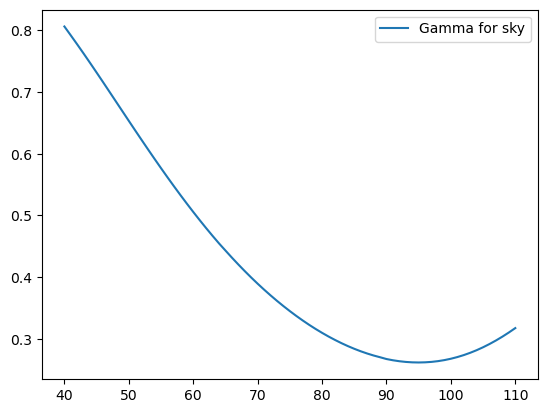

In [9]:
data = map(lambda x: [ x[0], x[1], x[2] ],
        np.loadtxt("/home/saurabhs/Documents/gopi/Saras_New/saras3_S11_200mm_above_water.s1p", skiprows=5))

d=list(data) #List of the format [Frequency, Magnitude, Phase (in degrees)]
c=const.c  # speed of light (m/s)
v=[d[i][0] for i in range(len(d))] #frequency
df=pd.read_csv('/home/saurabhs/Documents/gopi/Saras_New/S11_for_freq.csv')
#rlc = df[df.columns[1]].values.tolist()

gamma_Asky=[d[i][1] for i in range(len(v))]
v_MHz=np.array(v)/1e6

plt.plot(v_MHz, gamma_Asky, label="Gamma for sky")
plt.legend()

[-1.20013123e-11  6.04175607e-09 -1.24392165e-06  1.34628657e-04
 -7.91822329e-03  2.22071051e-01 -1.40950769e+00]


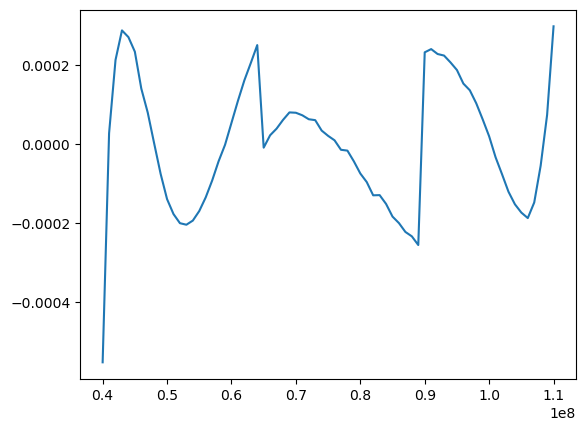

In [10]:
#Residuals of the fit
cc=np.polyfit(v_MHz, gamma_Asky, 6)
print(cc)
fit = np.polyval(cc,v_MHz)
res1=fit-gamma_Asky
plt.plot(v,res1)

### Power Law  representation of PSky

In [11]:
#PA for Sky
Po=200          #Kelvin
vo=150*1e6      #Hz
a=2.5           #spectral index
P_sky= [Po*(k/vo)**-a for k in v_MHz] 

## Sim Sky Model

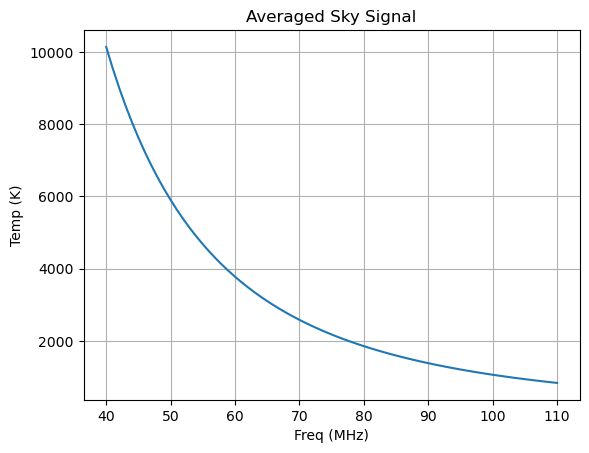

In [12]:
path_to_sig='/home/saurabhs/Documents/gopi/Saras_New/cosine_beam_sky_40_110MHz.txt'
path_to_freq1='/home/saurabhs/Documents/gopi/Saras_New/freq_40_110.txt'
PSky=np.loadtxt(path_to_sig)
#freq=np.loadtxt(path_to_freq1)*1e6
plt.plot(v_MHz, PSky)
plt.xlabel("Freq (MHz)")
plt.ylabel("Temp (K)")
plt.title("Averaged Sky Signal")
plt.grid()

### No MilkyWay in view PSky signal

(71,)


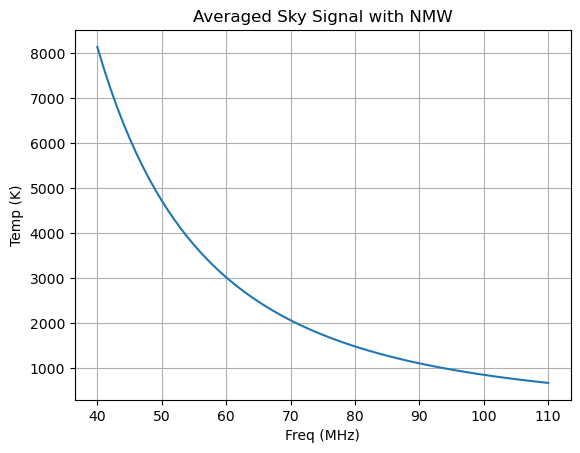

In [13]:
NMW_sky_data=np.load('cosine_sq_NMW.npy')
NMW_sky_avg=np.mean(NMW_sky_data, axis=0)
print(NMW_sky_avg.shape)
plt.plot(v_MHz,NMW_sky_avg)
plt.xlabel("Freq (MHz)")
plt.ylabel("Temp (K)")
plt.title("Averaged Sky Signal with NMW")
plt.grid()

### Fitting Sky Data

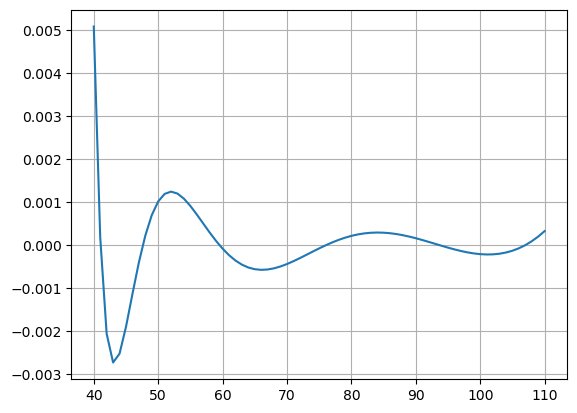

0.0009330871068585219


In [14]:
cc_sky_log=np.polyfit(np.log10(v_MHz), np.log10(NMW_sky_avg),5)

fit_sky_log = np.polyval(cc_sky_log,np.log10(v_MHz))
fit_sky_K=np.power(10.0, fit_sky_log, dtype=np.float64)
res_sky=fit_sky_K-NMW_sky_avg

#plt.plot(PSky)
#plt.plot(fit_sky_K)
plt.plot(v_MHz,res_sky)
plt.grid()
plt.show()

print(np.std(res_sky))

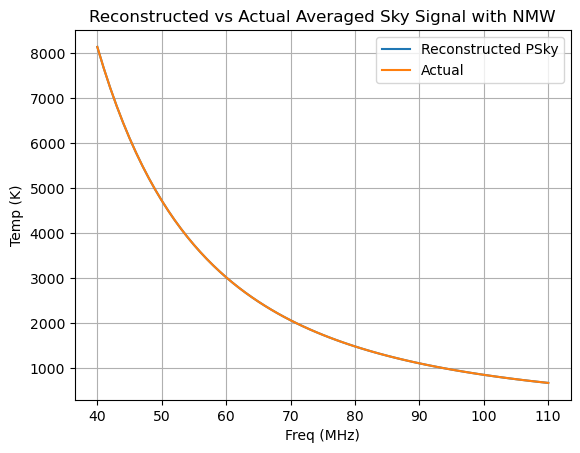

In [15]:
# Reconstructing the sky signal
PSky_log=np.polyval(cc_sky_log, np.log10(v_MHz))
PSky= np.power(10.0, PSky_log, dtype=np.float64)
plt.plot(v_MHz, PSky, label='Reconstructed PSky' )
plt.plot(v_MHz, NMW_sky_avg, label= "Actual" )
plt.xlabel("Freq (MHz)")
plt.ylabel("Temp (K)")
plt.title("Reconstructed vs Actual Averaged Sky Signal with NMW")
plt.legend()
plt.grid()
plt.show()

## Model

### For Sky

In [16]:
def Compute_Tmeas_Sky(PA, Pref, S11_params, PN, gamma_N, f, l, v): 
    
    req_freq=np.array(v)
    A = np.zeros_like(req_freq, dtype=float)
    B = np.zeros_like(req_freq, dtype=float)
    C = np.zeros_like(req_freq, dtype=float)
    l=l
    itr=9
    Tmeas=[]
    phi_A=0
    phi_N=0
    phi_f=0
    P_ref=Pref
    c=const.c
    
    #estimating Gamma_A
    p0,p1,p2,p3,p4,p5,p6=S11_params
    gamma_A=np.polyval([p0*1e-11, p1*1e-9, p2*1e-06, p3*1e-04, p4*1e-03, p5*1e-1, p6],req_freq)

    PA=PA
    phi=(4*math.pi*(req_freq*1e6)*l)/(0.7*c) #frequency should be in Hz
    #print(phi.size)
    for n in range(itr):
        # For A term: l index sum
        l_values = np.arange(n + 1)
        sum_l = np.sum(np.cos((2 * l_values[:, None] - n) * (phi_N + phi_A + phi)), axis=0)
        #print(sum_l.size)
        # For C term: c index sum (same structure as A)
        c_values = np.arange(n + 1)
        sum_c = np.sum(np.cos((2 * c_values[:, None] - n) * (phi_N + phi_A + phi)), axis=0)

        # Powers
        gammaA_pow_n = np.abs(gamma_A)**n
        gammaN_pow_n = np.abs(gamma_N)**n

        # A term update
        A += gammaA_pow_n * gammaN_pow_n * sum_l

        # B term update
        B += 2 * np.abs(f) * (np.abs(gamma_A)**(n + 1)) * gammaN_pow_n * \
             np.cos(phi_f + (n + 1)*(phi_A + phi) + n*phi_N)

        # C term update
        C += gammaA_pow_n * gammaN_pow_n * sum_c

    #Tmeas = (PA * A - Pref) + PN * (B + (np.abs(f)**2) * (np.abs(gamma_A)**2) * A)
    
    Tmeas = (PA*(1-np.abs(gamma_A)**2) * A - Pref)+ PN * (B + (np.abs(f)**2) * (np.abs(gamma_A)**2) * C)

    return Tmeas
  

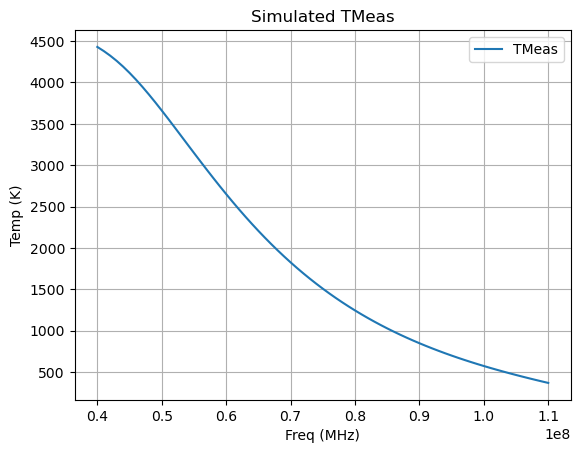

In [17]:
#Test Signal
PSky_coeffs=cc_sky_log
PSky_log=np.polyval(PSky_coeffs, np.log10(v_MHz))
PA=np.power(10.0, PSky_log, dtype=np.float64)
Pref=300
S11_params=[-1.20013123,  6.04175607, -1.24392165,  1.34628657, -7.91822329, 2.22071051, -1.40950769]
PN=70
gN=0.3
f=0.1
l=0.15
T=Compute_Tmeas_Sky(PA, Pref, S11_params, PN, gN, f, l, v_MHz)
#T1=Compute_Tmeas_Sky(2.5, 200, 300, -1.20013123,  6.04175607, -1.24392165,  1.34628657, -7.91822329, 2.22071051, -1.40950769, 70, 0.3, 0.1, 0.15,v,12)
plt.plot(v,T, label="TMeas")
plt.xlabel("Freq (MHz)")
plt.ylabel("Temp (K)")
plt.title("Simulated TMeas")
plt.legend()
plt.grid()
plt.show()

### For Open

In [44]:
def Compute_Tmeas_Open(PA, Pref, gamma_A, PN, gamma_N, f, l, req_freq): 
    req_freq=np.array(req_freq)
    A = np.zeros_like(req_freq, dtype=float)
    B = np.zeros_like(req_freq, dtype=float)
    C = np.zeros_like(req_freq, dtype=float)
    l=l
    itr=3
    Tmeas=[]
    phi_A=0
    phi_N=0
    phi_f=0
    P_ref=Pref
    c=const.c
    
    gamma_A=gamma_A
    
    phi=(4*math.pi*(req_freq*1e6)*l)/(0.7*c)
    #print(phi.size)
    for n in range(itr):
        # For A term: l index sum
        l_values = np.arange(n + 1)
        sum_l = np.sum(np.cos((2 * l_values[:, None] - n) * (phi_N + phi_A + phi)), axis=0)
        #print(sum_l.size)
        # For C term: c index sum (same structure as A)
        c_values = np.arange(n + 1)
        sum_c = np.sum(np.cos((2 * c_values[:, None] - n) * (phi_N + phi_A + phi)), axis=0)

        # Powers
        gammaA_pow_n = np.abs(gamma_A)**n
        gammaN_pow_n = np.abs(gamma_N)**n

        # A term update
        A += gammaA_pow_n * gammaN_pow_n * sum_l

        # B term update
        B += 2 * np.abs(f) * (np.abs(gamma_A)**(n + 1)) * gammaN_pow_n * \
             np.cos(phi_f + (n + 1)*(phi_A + phi) + n*phi_N)

        # C term update
        C += gammaA_pow_n * gammaN_pow_n * sum_c

    #Tmeas = (PA * A - Pref) + PN * (B + (np.abs(f)**2) * (np.abs(gamma_A)**2) * A)
    
    Tmeas = (PA * A - Pref) + PN * (B + (np.abs(f)**2) * (np.abs(gamma_A)**2) * C)

    return Tmeas
  

## 21cm signal

In [19]:
path_to_file = '/home/saurabhs/Documents/gopi/Saras_New/Data_18March_wMFP.mat'
path_to_freq = '/home/saurabhs/Documents/gopi/Saras_New/freq_saras.txt'

data     = scipy.io.loadmat(path_to_file)
data     = data['Data2']/1e3  # Kelvin units

fr       = np.loadtxt(path_to_freq) #Frequency in MHz
signal_function   = interpolate.interp1d(fr, data, fill_value="extrapolate")

In [20]:
F_MIN = 40 # define your own

F_MAX = 110 # define your own

NO_OF_CHANNELS = len(v_MHz) # define your own

freq_array = np.linspace(F_MIN, F_MAX, NO_OF_CHANNELS) 

signals = signal_function(freq_array)

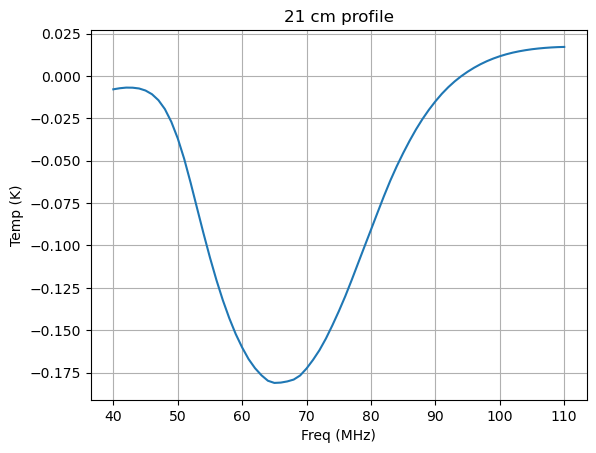

In [21]:
sig_idx = 63
sig21cm=signals[sig_idx]

plt.plot(v_MHz, sig21cm)
plt.title('21 cm profile')
plt.xlabel('Freq (MHz)')
plt.ylabel('Temp (K)')
plt.grid()
plt.show()

###  Open Run Data

In [22]:
data = map(lambda x: [ x[0], x[1], x[2] ],
        np.loadtxt("/home/saurabhs/Documents/gopi/Saras_New/saras3_S11_200mm_above_water.s1p", skiprows=5))

d=list(data) #List of the format [Frequency, Magnitude, Phase (in degrees)]
c=const.c  # speed of light (m/s)
freq=[d[i][0] for i in range(len(d)-1)] #frequency
freq_MHz=np.array(freq)/1e6

In [23]:
seed_main=60

## MCMC for Open

In [47]:
########## Define the log-likelihood function
def log_likelihood_o(params,seed,v,s,TA_exp):
    
    PA, Pref, gamma_A, PN, gamma_N, f, l = params
    
    np.random.seed(seed)
    
    # Compute model TA
    TA_model = Compute_Tmeas_Open(PA, Pref, gamma_A, PN, gamma_N, f, l,v)
    TA_model=np.array(TA_model)

    # Compute chi-squared with weights
    
    chi2 = np.sum([((TA_exp - TA_model)/s)** 2 ]) 

    return -0.5*chi2 #- np.log(math.sqrt(2*np.pi)*s)  # Likelihood function

########## Define the log-prior function
def log_prior_o(params):
    
    PA, Pref, gamma_A, PN, gamma_N, f, l = params

    if ((0 <= gamma_A <= 1) and (0 <= gamma_N <= 1) and PA>0 and Pref>0 and PN>0 and f>0 and 0<l<0.5) : 
            return 0.0  # Reject sample
    return -np.inf # Uniform prior

######### Define the full log-probability function

def log_probability_o(params,seed,v,s,TA_exp):
    lp = log_prior_o(params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_o(params,seed,v,s,TA_exp)

########### MCMC

def evolve_MCMC_o(**kwargs):# Define parameter names

    ndim = 7  # Number of parameters
    nwalkers = 150  # Number of MCMC walkers
    nsteps = kwargs["nsteps"]  # Number of MCMC steps per walker
    
    ## Initialize walkers around a random point in parameter space
    initial_value=kwargs["initial_value"]
    
    seed=kwargs["seed"]
    v=kwargs["v"]
    s=kwargs["s"]
    TA_exp=kwargs["TA_exp"]

    np.random.seed(seed+1)
    ## Starting positions for the walkers (making sure that the initial positions satisfy the priors)
    
    pos_valid = []
    while len(pos_valid) < nwalkers:
        
        trial = np.array(initial_value) + \
            1e-1*np.random.normal(size=ndim)
        
        if np.isfinite(log_prior_o(trial)):
            pos_valid.append(trial)
    pos = np.array(pos_valid)
    
    #pos = np.array(initial_value)[None,:] + 1e-1*np.random.normal(0,1,size=(nwalkers,ndim))

    
    ## for making sure only positive positional values
    """
    for idim in range(ndim):
        ind_pos = pos[:,idim]<0
        pos[ind_pos,idim] = np.abs(pos[ind_pos,idim])
    """ 

    
    ## Set up the MCMC sampler
    with Pool() as pool:

        sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability_o,\
                                        args=(seed,v,s,TA_exp), pool=pool)

        ## Run MCMC

        print("Running MCMC...")
        sampler.run_mcmc(pos, nsteps, progress=True)
    
    ## Extract the samples
    burn=900
    full_samples=sampler.get_chain()
    samples = sampler.get_chain(discard=burn, flat=True)
    tau = sampler.get_autocorr_time(discard=burn, tol=0, quiet=True)
    print("tau (best-effort):", tau)
    
    ## Compute log-likelihoods for all samples
    
    log_likes = np.array([log_likelihood_o(p,seed,v,s,TA_exp) \
                          for p in samples])
    
    ## Acceptance Fraction
    
    af_per_walker = sampler.acceptance_fraction      # array shaped (nwalkers,)
    af_mean = af_per_walker.mean()
    
    ## Find the index of the maximum likelihood
    
    max_likelihood_index = np.argmax(log_likes)
    
    ## Get the best-fit parameters
    
    best_fit_params = samples[max_likelihood_index].tolist()

    return full_samples,samples,best_fit_params, pos, af_mean

In [48]:
#evolve MCMC
# Parameters:
PA=0
Pref=300
gamma_A=1
PN=70
gamma_N=0.3
f=0.1
l=0.15

ip_params=[PA, Pref, gamma_A, PN, gamma_N, f, l] #input parameters
nsteps=1700
initials=[0.007,303,0.97,70.7,0.29,0.1,0.13]
s=0.001
seed=seed_main+1
TA_exp=Compute_Tmeas_Open(*ip_params,v_MHz)
TA_exp=np.array(TA_exp)+ np.random.normal(0,0.001,len(v_MHz))
kwargs={"s":s, "seed":seed, "TA_exp":TA_exp, "nsteps":nsteps, "ip_params":ip_params, "v":v_MHz, "initial_value":initials}
full_samples_o, samples_o, best_fit_params_o,pos, af_mean= evolve_MCMC_o(**kwargs)


Running MCMC...


100%|██████████████████████████████████████| 1700/1700 [00:15<00:00, 108.43it/s]


tau (best-effort): [84.86097604 83.71080835 85.11070797 89.23721318 85.36562173 84.25441723
 87.01322199]


In [49]:
print(af_mean, best_fit_params_o)

0.11927450980392157 [1.185426420819585, 301.11588488893443, 0.8752206658643106, 69.31409056162991, 0.3473857092102884, 0.10896148118557003, 0.1505731106124883]


In [ ]:
# parameter_names = ["PA","Pref", "gamma_A", "PN", "gamma_N", "f","l"]
# #corner plot 
# fig = corner.corner(samples_o, labels=parameter_names, truths=ip_params, color='C1',  # Change color of the contour and histograms
# hist_kwargs={"color": "royalblue"},  # Set histogram color
# contour_kwargs={"colors": ["royalblue"]},  # Set contour color
# truth_color="green" ) # Color for the true parameter values)
# plt.suptitle("Open Param Est with gA, gN, PA, PN, f & l Constrained", fontsize=25)
# #plt.savefig('/home/saurabhs/Documents/gopi/Saras_Model/Untitled Folder/Open_All_15cm_1.png', dpi=300)
# plt.show()

# #print("Expected Paramerters:",ip_params)
# print("Best-fit parameters (Maximum Likelihood Estimate):", best_fit_params_o)

## MCMC for Sky Sim data with S11 fixed

In [60]:
########### Define the log-likelihood function
def log_likelihood_full(params,seed,v,s,TA_exp,S11_params):

    np.random.seed(seed)
    
    # Compute model TA

    a, P0, P1, P2, P3, P4, P5, Pref, PN, gamma_N, f, l = params
    PSky_log=np.polyval([P0, P1, P2, P3, P4, P5],np.log10(v))
    PA = np.power(10.0, PSky_log, dtype=np.float64)
    TA_model = Compute_Tmeas_Sky(PA, Pref, S11_params, PN, gamma_N, f, l,v)

    TA_model=np.array(TA_model)+a*signal#+b*s

    # Compute chi-squared
    chi2 = np.sum([((TA_exp - TA_model)/s)** 2 ]) 

    return -0.5*chi2 #- np.log(math.sqrt(2*np.pi)*s)

########## Define the log-prior function
def log_prior_full(params):

    a, P0, P1, P2, P3, P4, P5, Pref, PN, gamma_N, f, l = params
    #v=kwargs["v"]
    #PA, p0, p1, p2, p3, p4, p5, p6, PN, gamma_N, f, l = params
    #gamma_A=np.polyval([p0*1e-48, p1*1e-39, p2*1e-31, p3*1e-23, p4*1e-15, p5*1e-08, p6*1e-01],v)
    
    PSky_log=np.polyval([P0, P1, P2, P3, P4, P5],np.log10(v))
    PA= np.power(10.0, PSky_log, dtype=np.float64)
    if (a>0 and 0<=gamma_N<=1 and np.amin(PSky_log)>0 and np.amax(PSky_log)<300 and Pref>0 and PN>0 and f>0 and 0<l<0.50): #np.amin(gamma_A)>=0 and np.amax(gamma_A)<=1 and ):
        return 0.0  # Accept sample
    
    return -np.inf # Reject prior
        
    
######### Define the full log-probability function
    
def log_probability_full(params,seed,v,s,TA_exp,S11_params):
    lp = log_prior_full(params)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_full(params, seed, v, s, TA_exp, S11_params)


########## MCMC for RLC Coeffs.
def evolve_MCMC_Full(**kwargs):

    
    ## Number of walkers and steps
    
    ndim = 12  # Number of parameters
    nwalkers = 100  # Number of MCMC walkers
    nsteps = kwargs["nsteps"]  # Number of MCMC steps per walker
    
    ## Initialize walkers around a random point in parameter space
    
    initial_value=kwargs["initial_value"]
    
    seed=kwargs["seed"]
    v=kwargs["v"]
    s=kwargs["s"]
    TA_exp=kwargs["TA_exp"]
    S11_params = kwargs["Sky_S11_params"]
    signal=kwargs["signal"]
    #PA_cc=kwargs["PA_Coeffs"]

    ## Starting positions for the walkers (making sure that the initial positions satisfy the priors)
    np.random.seed(seed+1)
    
    pos_valid = []
    while len(pos_valid) < nwalkers:
        trial =np.array(initial_value) + 1e-1 * np.random.normal(size=ndim)# initial_value + 1e-1 * np.random.randn(ndim)
        #print(len(trial))
        if np.isfinite(log_prior_full(trial)):
            pos_valid.append(trial)
    pos = np.array(pos_valid)
    
    #pos = np.array(initial_value)[None,:] + 1e-1*np.random.normal(0,1,size=(nwalkers,ndim))

    ## for making sure only positive positional values
    """
    for idim in range(ndim):
        ind_pos = pos[:,idim]<0
        pos[ind_pos,idim] = np.abs(pos[ind_pos,idim])
    """ 

    
    ## Set up the MCMC sampler
    with Pool() as pool:

        sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability_full,\
                                        args=(seed,v,s,TA_exp,S11_params), pool=pool)

        ## Run MCMC

        print("Running MCMC...")
        sampler.run_mcmc(pos, nsteps, progress=True)
    
    ## Extract the samples
    burn=4500
    full_samples=sampler.get_chain()
    samples = sampler.get_chain(discard=burn, flat=True)
    #tau = sampler.get_autocorr_time(discard=burn, tol=0, quiet=True)
    ## Acceptance Fraction
    af_per_walker = sampler.acceptance_fraction      # array shaped (nwalkers,)
    af_mean = af_per_walker.mean()
    #print("tau (best-effort):", tau)
    #print("tau_max:", np.max(tau))
    
    return full_samples,samples, pos, af_per_walker, af_mean#, tau

RMSE:0.0010754069900122838


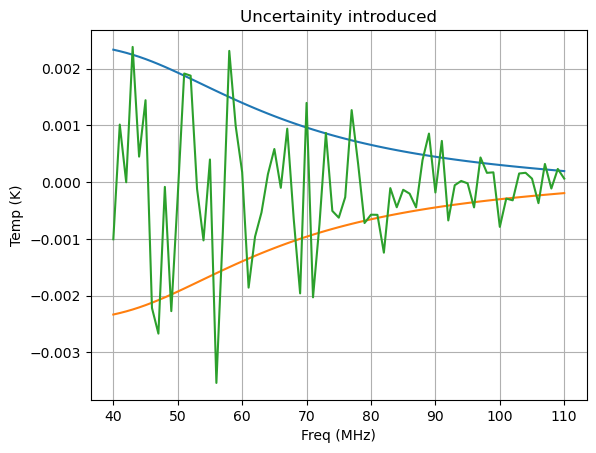

In [61]:
# S11 params
Sky_S11_params=[-1.20013123,  6.04175607, -1.24392165,  1.34628657,\
                -7.91822329,  2.22071051, -1.40950769]
seed=seed_main+1
np.random.seed(seed)
p0, p1, p2, p3, p4, p5, p6=Sky_S11_params

# True values of the system parameters
PSky_log_t=np.polyval(PSky_coeffs,np.log10(v_MHz))
PA_t = np.power(10.0, PSky_log_t, dtype=np.float64)
Pref_t,PN_t,gN_t,f_t,l_t=[300,70,0.3,0.1,0.15]
TMeas_=Compute_Tmeas_Sky(PA_t, Pref_t, S11_params, PN_t, gN_t, f_t, l_t,v_MHz)#T21

t=1000*3600 # time in secs
freq_res=np.mean(np.diff(v)) # freq resolution
sigma_mu=TMeas_/np.sqrt(t*freq_res) # deviation
uncert=np.random.normal(0,sigma_mu,size=len(v))

a_actual=0
TMeas_exp=np.array(TMeas_)+uncert+a_actual*sig21cm ## Expected Tmeas with 21cm signal
#TMeas_exp_nosig= np.array(TMeas_)+uncert ## Expected Tmeas without 21cm signal

plt.plot(v_MHz, sigma_mu)
plt.plot(v_MHz, -sigma_mu)
plt.plot(v_MHz, uncert)
plt.title('Uncertainity introduced')
plt.xlabel('Freq (MHz)')
plt.ylabel('Temp (K)')
plt.grid()

print(f"RMSE:{np.sqrt(np.mean((uncert)**2))}")

In [62]:
#evolve MCMC full with initials for system parameters from Open

seed=seed_main+2
P0, P1, P2, P3, P4, P5=PSky_coeffs
a=0 ## multiplication factor for the signal
PAo, Prefo, gAo, PNo, gNo, fo, lo= best_fit_params_o ## In case initials are taken from best fit of the open run
initials=[a, P0, P1, P2, P3, P4, P5, Prefo, PNo, gNo, fo, lo]  ##initials for mcmc walkers
nsteps=5000
signal= sig21cm ## 21cm signal

s=uncert ## uncertainity

kwargs = {"s":s, "v":v_MHz, "seed":seed, "nsteps":nsteps, "initial_value":initials, \
          "TA_exp":TMeas_exp, "Sky_S11_params":Sky_S11_params, "signal":signal} #"ip_params":ip_params}

full_samples_full, samples_full, initial_pos, af_per_walker, af_mean= evolve_MCMC_Full(**kwargs)

/tmp/ipykernel_2633093/999170834.py:29: RuntimeWarning: overflow encountered in power
  PA= np.power(10.0, PSky_log, dtype=np.float64)


Running MCMC...


100%|███████████████████████████████████████| 5000/5000 [00:52<00:00, 95.89it/s]


In [63]:
 ## Compute log-likelihoods for all samples
log_likes = np.array([log_likelihood_full(p,seed,v_MHz,s,TMeas_exp,S11_params) for p in samples_full])

## Find the index of the maximum likelihood

max_likelihood_index = np.argmax(log_likes)

## Get the best-fit parameters

best_fit_params = samples_full[max_likelihood_index].tolist()

In [64]:
af_mean, seed

(0.19809200000000002, 62)

In [65]:
best_fit_params

[0.005471692346906216,
 0.04442214282154751,
 -0.522041974539571,
 2.398143708197489,
 -5.454527428087247,
 3.703428142931747,
 5.0880889756456655,
 303.0959453865698,
 69.01735522492532,
 0.2976662600079089,
 0.1007942846549562,
 0.14894940015956326]

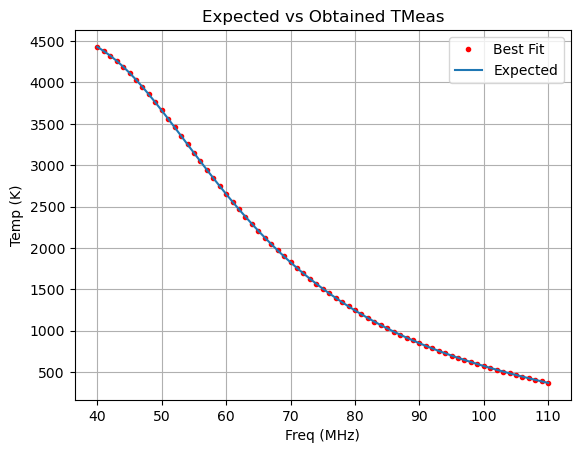

In [66]:
a, P0, P1, P2, P3, P4, P5, Pref, PN, gN, f, l=best_fit_params
PSky_cc_best=[P0,P1,P2,P3,P4,P5]
PSky_log_best=np.polyval(PSky_cc_best,np.log10(v_MHz))
PA_best = np.power(10.0, PSky_log_best, dtype=np.float64)
TMeas_best=Compute_Tmeas_Sky(PA_best, Pref, S11_params, PN, gN, f, l,v_MHz)+a*sig21cm
plt.plot(v_MHz,TMeas_best,'.r', label="Best Fit")
plt.plot(v_MHz,TMeas_exp, label="Expected")
plt.title('Expected vs Obtained TMeas')
plt.xlabel('Freq (MHz)')
plt.ylabel('Temp (K)')
plt.legend()
plt.grid()

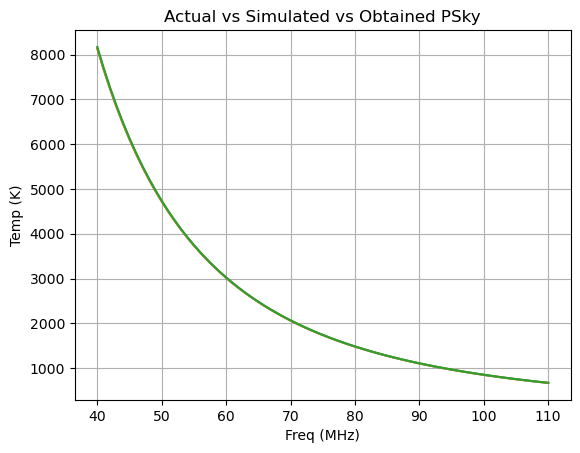

In [67]:
# Actual vs Simulated vs Obtained PSky

plt.plot(v_MHz,NMW_sky_avg,label="Actual")
plt.plot(v_MHz,PA_t,label="Simulated")
plt.plot(v_MHz,PA_best, label='Obtained')
plt.title('Actual vs Simulated vs Obtained PSky')
plt.xlabel('Freq (MHz)')
plt.ylabel('Temp (K)')
plt.grid()



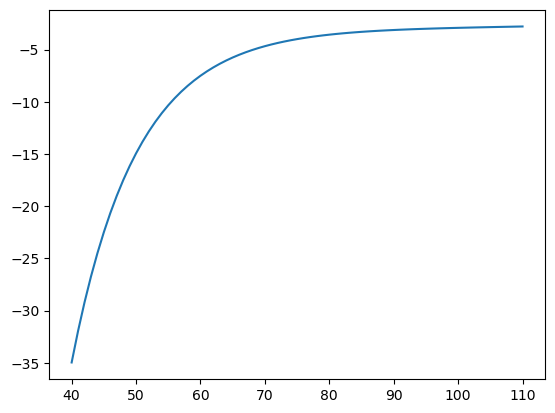

In [68]:
plt.plot(v_MHz,PA_t-PA_best)

## Generating and Saving Pickel File

In [69]:
#Saving in a pickel file
# Ask user for confirmation
parameter_names = ["a","P0","P1","P2","P3","P4","P5","Pref", "PN", "gN", "f", "l"]
true_params=[a_actual, PSky_coeffs, Pref_t, PN_t, gN_t, f_t, l_t]
seed=seed
print(seed)
#confirm = input("Do you want to save the pickle file? (y/n): ").strip().lower()
confirm="y"
if confirm == "y":
    result={"seed":seed, "req_freq":v_MHz, "full_samples":full_samples_full, "samples":samples_full, "best_fit":best_fit_params,\
            "param_names":parameter_names, "true_params":true_params, "S11_params": Sky_S11_params, "Real Data":TMeas_exp, "sig21cm": sig21cm}#,"Mean Acceptance Factor":af_mean, "Auto corr time":tau}

    with open(f"results_sky_{seed}_a1s1_simdata.pkl", 'wb') as file:  # open a text file
        pickle.dump(result, file) # serialize the list

    file.close()
else:
     print("Save cancelled.")

62


In [125]:
for key, value in result.items():
    try:
        pickle.dumps(value)
    except Exception as e:
        print(f"❌ Cannot pickle {key}: {e}")

In [60]:
print(type(PSky_cc), type(Pref), type(PN), type(gN), type(f), type(l))


<class 'list'> <class 'float'> <class 'float'> <class 'float'> <class 'float'> <class 'float'>


In [58]:
seed

11